# causaldyn-bench — scoring *decisions*, not one-step error

Most ML benchmarks rank models by one-step accuracy, where gradient-boosted trees are very hard to
beat. But a good **prediction** is not a good **decision**: decisions play out over a horizon, under
constraints, and depend on the *interventional* effect of the action — axes where trees, naive causal
reads, and myopic policies fall down. `causaldyn-bench` scores every competitor on the axis it deserves:

| track | question | metric |
|---|---|---|
| **A** one-step | `x_t,u_t → x_{t+1}` | RMSE |
| **B** rollout | `x_t,u_{t:t+H} → x_{t+1:t+H}` | rollout RMSE |
| **C** counterfactual | `x_{t+1}(do(u))` under confounding | \|effect − truth\| |
| **D** control | `u_t = π(x_t)` under constraints | regret vs oracle |
| **D** adaptive-CV | split a GPU budget across video streams | regret vs oracle |
| **E** systems | control-solve latency | ms |

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from causaldyn_bench import run_all, to_frame

results = run_all()  # trains the dynamics models + runs every track once (~1 min)
frame = to_frame(results)
frame

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


,track,method,metric,value,lower_is_better
0,A-onestep,known-only,rmse,0.070097,True
1,A-onestep,hybrid-CHC,rmse,0.001653,True
2,A-onestep,dlm,rmse,0.044682,True
3,A-onestep,tree-surrogate,rmse,0.033452,True
4,B-rollout,known-only,rmse,0.467598,True
5,B-rollout,hybrid-CHC,rmse,0.026027,True
6,B-rollout,dlm,rmse,0.356303,True
7,B-rollout,tree-surrogate,rmse,0.465236,True
8,C-effect,naive,ate_error,1.199846,True
9,C-effect,backdoor-CHC,ate_error,0.001464,True


## One figure per track

Each track is sorted on its own metric (lower is better everywhere here). The regret tracks span
several orders of magnitude, so they use a log scale with a small floor to keep the near-zero bars
visible.

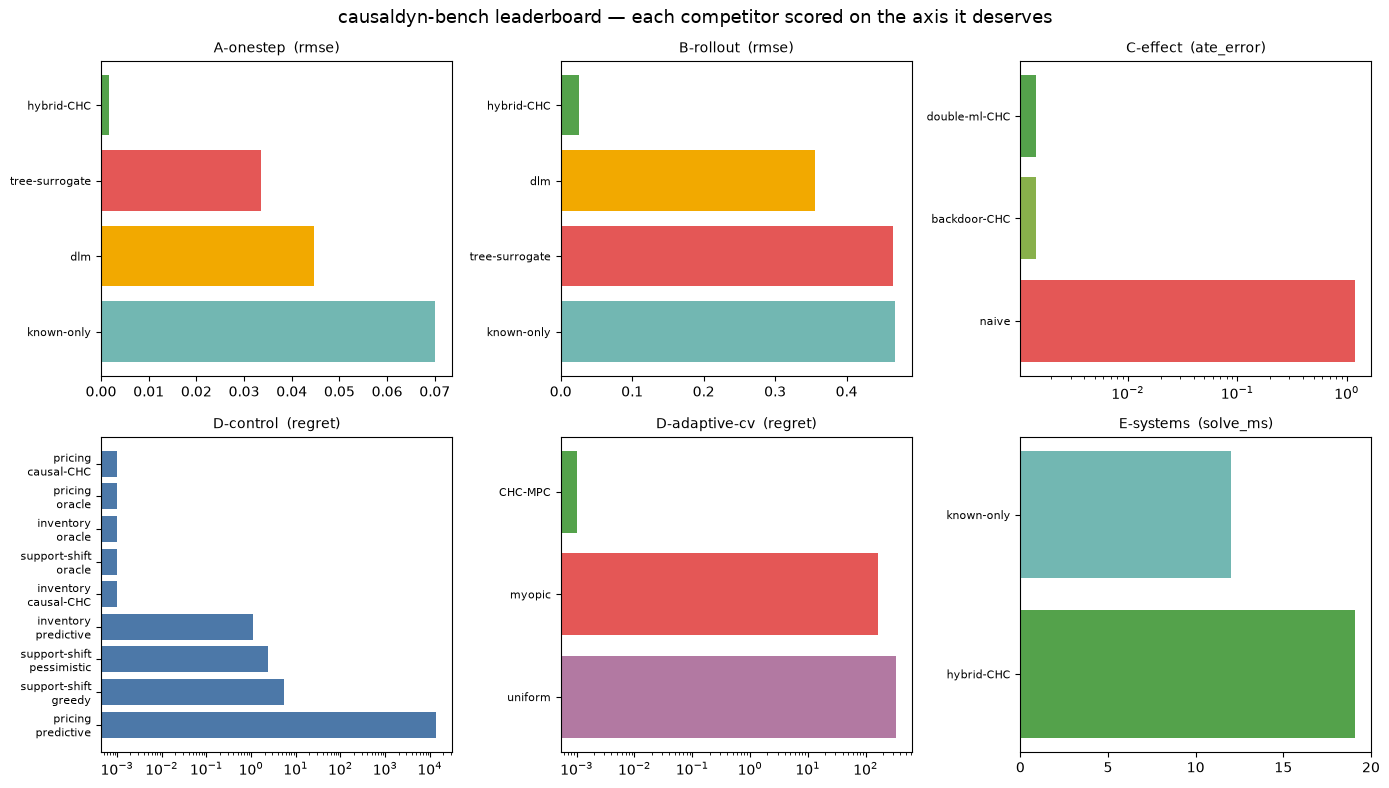

In [2]:
COLOR = {
    "hybrid-CHC": "#54A24B", "known-only": "#72B7B2", "dlm": "#F2A900", "tree-surrogate": "#E45756",
    "double-ml-CHC": "#54A24B", "backdoor-CHC": "#88B04B", "naive": "#E45756",
    "CHC-MPC": "#54A24B", "myopic": "#E45756", "uniform": "#B279A2",
}


def plot_track(ax, track, log=False, floor=1e-3):
    sub = frame[frame["track"] == track].sort_values("value")
    vals = sub["value"].clip(lower=floor) if log else sub["value"]
    colors = [COLOR.get(m.split("/")[-1], "#4C78A8") for m in sub["method"]]
    ax.barh(range(len(sub)), vals, color=colors)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([m.replace("/", "\n") for m in sub["method"]], fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"{track}  ({sub['metric'].iloc[0]})", fontsize=10)
    if log:
        ax.set_xscale("log")


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_track(axes[0, 0], "A-onestep")
plot_track(axes[0, 1], "B-rollout")
plot_track(axes[0, 2], "C-effect", log=True)
plot_track(axes[1, 0], "D-control", log=True)
plot_track(axes[1, 1], "D-adaptive-cv", log=True)
plot_track(axes[1, 2], "E-systems")
fig.suptitle("causaldyn-bench leaderboard — each competitor scored on the axis it deserves", fontsize=13)
plt.tight_layout()
plt.show()

## The headline: a good predictor is not a good model to *plan* with

The tree and the data-driven linear model (DLM) are competitive — even best — on **one-step** error.
But roll them forward over a horizon and they drift, because neither respects the known physics. The
**hybrid** model (known dynamics + a small learned residual) is anchored and dominates the rollout —
which is what a controller actually uses.

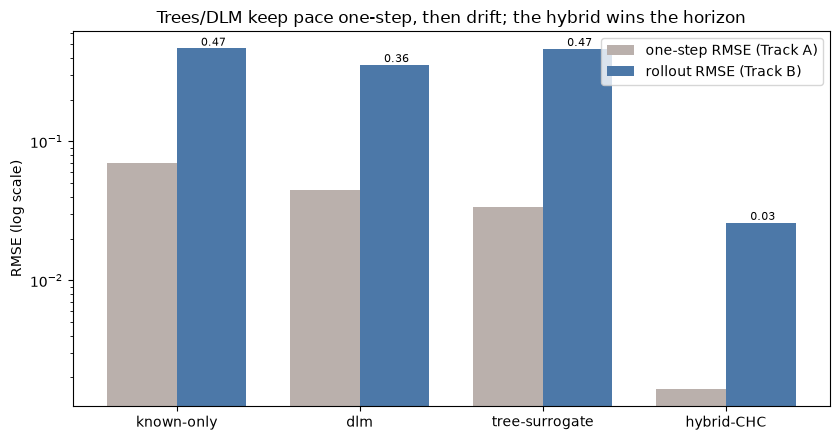

rollout RMSE — hybrid vs the best non-hybrid:
  hybrid 0.026  vs  0.356  ->  14x lower


In [3]:
dyn = ["known-only", "dlm", "tree-surrogate", "hybrid-CHC"]
a = {r.method: r.value for r in results if r.track == "A-onestep"}
b = {r.method: r.value for r in results if r.track == "B-rollout"}
x = np.arange(len(dyn))
w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - w / 2, [a[m] for m in dyn], w, label="one-step RMSE (Track A)", color="#BAB0AC")
ax.bar(x + w / 2, [b[m] for m in dyn], w, label="rollout RMSE (Track B)", color="#4C78A8")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(dyn)
ax.set_ylabel("RMSE (log scale)")
ax.set_title("Trees/DLM keep pace one-step, then drift; the hybrid wins the horizon")
ax.legend()
for i, m in enumerate(dyn):
    ax.text(i + w / 2, b[m], f" {b[m]:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print("rollout RMSE — hybrid vs the best non-hybrid:")
best_other = min(b[m] for m in dyn if m != "hybrid-CHC")
print(f"  hybrid {b['hybrid-CHC']:.3f}  vs  {best_other:.3f}  ->  {best_other / b['hybrid-CHC']:.0f}x lower")

## The decision tracks: prediction ≠ intervention ≠ myopia

On the control tracks the gap is not subtle. Under confounding, the naive effect is the wrong sign, so
a predictive controller drives the system away from target (pricing regret ~13,700 vs ~0). And a
priority-blind, load-proportional GPU split lets cheap streams crowd out critical ones, where the
constrained CHC-MPC matches the oracle.

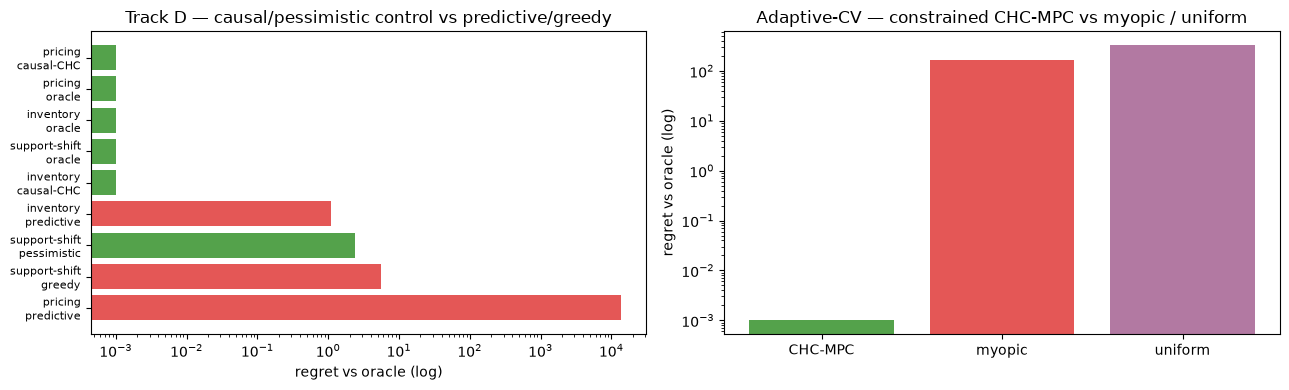

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
d = frame[frame["track"] == "D-control"].sort_values("value")
ax1.barh(range(len(d)), d["value"].clip(lower=1e-3),
         color=["#54A24B" if "causal" in m or "oracle" in m or "pessim" in m else "#E45756" for m in d["method"]])
ax1.set_yticks(range(len(d)))
ax1.set_yticklabels([m.replace("/", "\n") for m in d["method"]], fontsize=8)
ax1.invert_yaxis()
ax1.set_xscale("log")
ax1.set_xlabel("regret vs oracle (log)")
ax1.set_title("Track D — causal/pessimistic control vs predictive/greedy")

cv = frame[frame["track"] == "D-adaptive-cv"].sort_values("value")
ax2.bar(cv["method"], cv["value"].clip(lower=1e-3), color=[COLOR[m] for m in cv["method"]])
ax2.set_yscale("log")
ax2.set_ylabel("regret vs oracle (log)")
ax2.set_title("Adaptive-CV — constrained CHC-MPC vs myopic / uniform")
plt.tight_layout()
plt.show()

## Scope & honesty (read this before quoting the numbers)

These are **synthetic** tasks, chosen to exercise each axis, and the CHC-style method wins the decision
tracks partly *by construction of the data-generating processes*. That makes this a strong
**demonstration and regression harness** and a clean statement of the *framing* — score decisions, not
one-step error — but **not yet a moat**. A benchmark becomes a moat only with (1) real,
method-agnostic tasks that the authors do not control (the next target is **BOPTEST** HVAC control) and
(2) external adoption. The defensible contribution today is the framing and the reproducible,
multi-competitor comparison; the SOTA claims wait for the real tasks.